In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.signal as sc
import xarray as xr
np.seterr(divide='ignore')
import numpy.ma as ma

In [10]:
case = 'BOMEX'

In [11]:
arm_path = 'C:/Users/si818415/Documents/code/LES_analysis/data/ARM/'
bomex_path = 'C:/Users/si818415/Documents/code/LES_analysis/data/BOMEX/'

file_path = bomex_path
path='C:/Users/si818415/Documents/code/LES_analysis/data/'

In [12]:
if case=='BOMEX':
    dx=20
    z = np.arange(0, 3020, 20)
    z_i = 480 #1120

elif case=='ARM':
    dx=25
    z = np.arange(0, 4410, 10)
    z_i = 1120

In [7]:
C_sq_BOMEX_0 = np.load(bomex_path+f'C_sq_cond_14400_0.npy')



In [8]:
def get_Cs(Cs_sq):
    """ calculates C_s from C_s^2 by setting neg values to zero
    and sq rooting"""

    Cs_sq_copy = Cs_sq.copy()
    Cs_sq_copy[Cs_sq < 0] = 0
    Cs = np.sqrt(Cs_sq_copy)

    return Cs

NameError: name 'res' is not defined

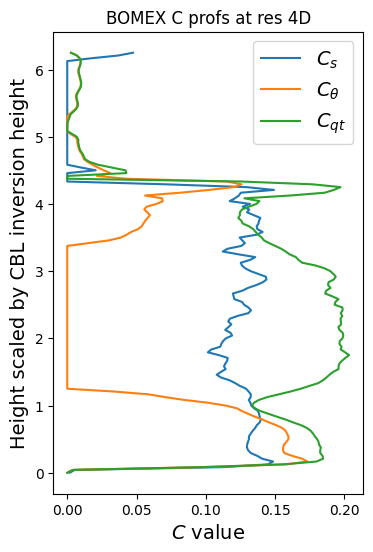

In [14]:
z_i = 480

plt.figure(figsize=(4,6))
plt.title(f'{case} C profs at res 4D')
plt.plot(get_Cs(C_sq_BOMEX_0)[0,0,0,:], z/z_i, label='$C_s$')
plt.plot(get_Cs(C_sq_BOMEX_0)[1,0,0,:], z/z_i, label='$C_\\theta$')
plt.plot(get_Cs(C_sq_BOMEX_0)[2,0,0,:], z/z_i, label='$C_{qt}$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('$C$ value', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
plt.savefig(f'{case}_C_profs_{res}.pdf', bbox_inches='tight')

In [66]:
Pr = Cs_sq/C_th_sq
Sc = Cs_sq/C_q_sq

In [64]:
# Pr[Pr > 2.95] = np.nan
# Pr[Pr < -0.45] = np.nan
#
# Sc[Sc > 2.95] = np.nan
# Sc[Sc < -0.45] = np.nan
#
# Pr = ma.masked_invalid(Pr)
# Sc = ma.masked_invalid(Sc)

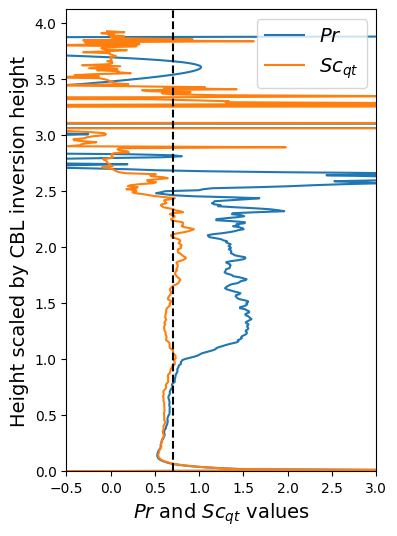

In [73]:
z_i = 1120

plt.figure(figsize=(4, 6))
plt.plot(Pr[0, :], z / z_i, label='$Pr$')
plt.plot(Sc[0, :], z / z_i, label='$Sc_{qt}$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('$Pr$ and $Sc_{qt}$ values', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
bottom0, top0 = plt.ylim()

plt.xlim(-0.5, 3.0)

plt.axvline(0.7, bottom0, top0, color='k', linestyle='dashed')

plt.ylim(0, top0)

plt.savefig('ARM_pr_25_50.pdf', bbox_inches='tight')

In [82]:
Cs_sq = np.load(path+f'Cs_sq_cond_32400.npy')[0]
np.shape(Cs_sq)

(7, 441)

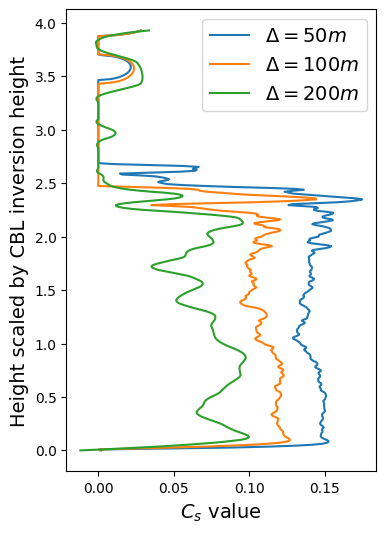

In [94]:
plt.figure(figsize=(4,6))
plt.plot(get_Cs(Cs_sq)[1,:], z/z_i, label='$\\Delta = 50m$')
plt.plot(get_Cs(Cs_sq)[2,:], z/z_i, label='$\\Delta = 100m$')
plt.plot(sc.savgol_filter(get_Cs(Cs_sq)[3,:], 21, 3), z/z_i, label='$\\Delta = 200m$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('$C_s$ value', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
plt.savefig('ARM_C_50_100_200.pdf', bbox_inches='tight')

In [87]:
def l_mix_MONC(Delta, Cs, z_in, k=0.4):
    l_mix = np.sqrt(1 / ((1 / (Cs * Cs * Delta * Delta)) + (1 / (k * k * z_in * z_in))))

    return l_mix

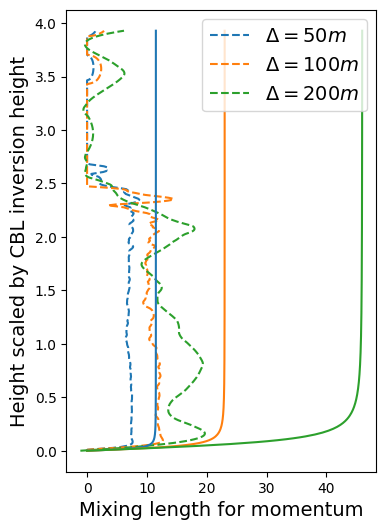

In [103]:
plt.figure(figsize=(4,6))
plt.plot(50*get_Cs(Cs_sq)[1,:], z/z_i, '--', label='$\\Delta = 50m$')
plt.plot(100*get_Cs(Cs_sq)[2,:], z/z_i, '--', label='$\\Delta = 100m$')
plt.plot(sc.savgol_filter(200*get_Cs(Cs_sq)[3,:], 51, 3), z/z_i, '--', label='$\\Delta = 200m$')
plt.plot(l_mix_MONC(50, 0.23, z), z/z_i, color='tab:blue')
plt.plot(l_mix_MONC(100, 0.23, z), z/z_i, color='tab:orange')
plt.plot(l_mix_MONC(200, 0.23, z), z/z_i, color='tab:green')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('Mixing length for momentum', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
plt.savefig('ARM_lmix_50_100_200.pdf', bbox_inches='tight')